<>:67: SyntaxWarning: invalid escape sequence '\m'
<>:67: SyntaxWarning: invalid escape sequence '\m'
C:\Users\yocan\AppData\Local\Temp\ipykernel_94496\1560293341.py:67: SyntaxWarning: invalid escape sequence '\m'
  g.set_axis_labels('NO2iation [W/m$^2$]', 'Ozone [$\mu$g/m$^3$]', size=22)
C:\Users\yocan\AppData\Local\Temp\ipykernel_94496\1560293341.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  avg_corrs = lagged_df.groupby(['site', 'season', 'lag']).apply(lambda g: g['NO2_lagged'].corr(g['WINDDIR_lagged'])).reset_index(name='correlation')


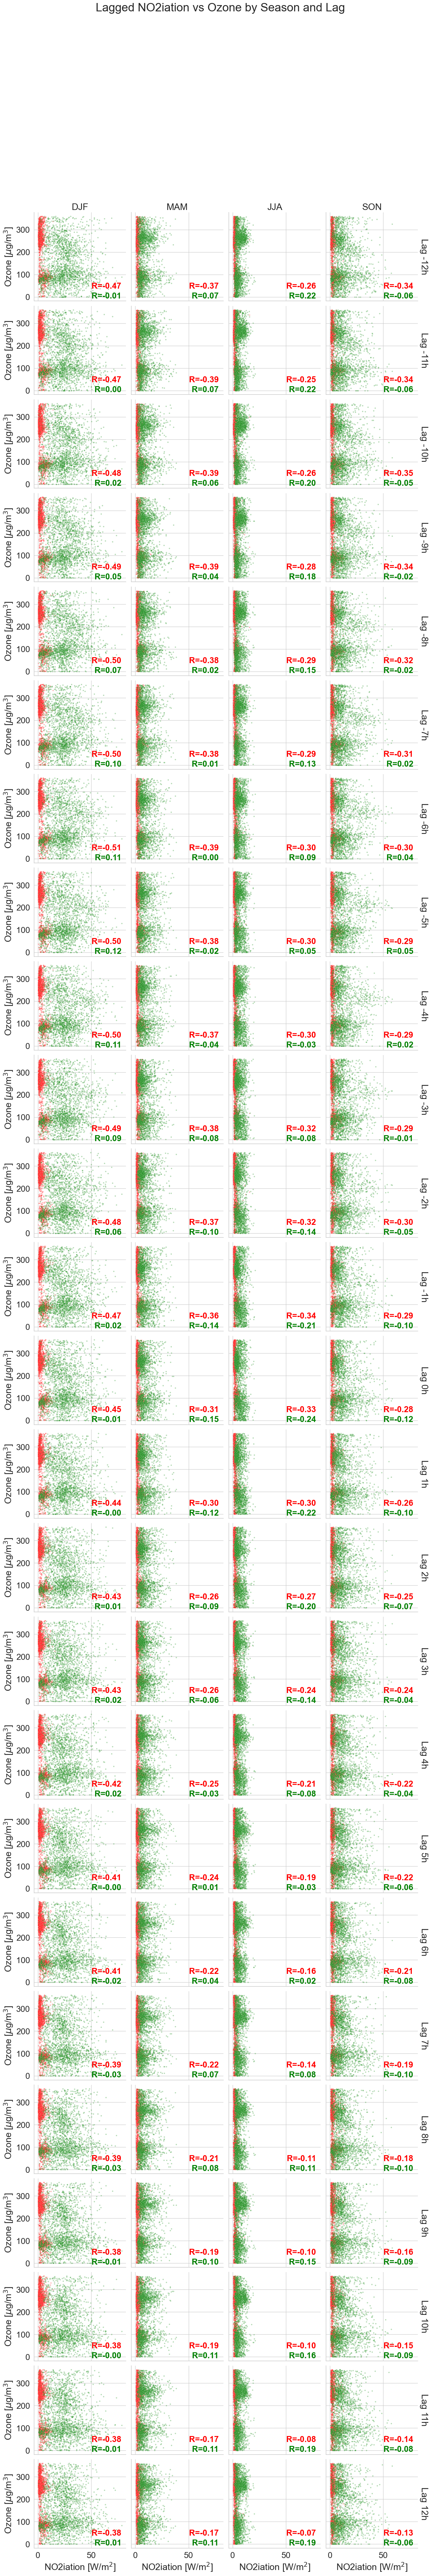

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load and clean the data
df = pd.read_csv('DATA.csv', sep=';', parse_dates=['TIME'], dayfirst=True)
df.replace({',': '.'}, regex=True, inplace=True)

# Convert relevant columns to numeric
df[['O3MAG', 'O3CHA', 'NO2MAG', 'NO2CHA']] = df[['O3MAG', 'O3CHA', 'NO2MAG', 'NO2CHA']].apply(pd.to_numeric, errors='coerce')

# Assign season
df['season'] = df['TIME'].dt.month.map({12: 'DJF', 1: 'DJF', 2: 'DJF', 3: 'MAM', 4: 'MAM', 5: 'MAM', 
                                        6: 'JJA', 7: 'JJA', 8: 'JJA', 9: 'SON', 10: 'SON', 11: 'SON'})

# Create a combined dataframe for CHA and MAG
df_full = pd.concat([
    df[['TIME', 'season', 'NO2CHA', 'O3CHA']].rename(columns={'NO2CHA': 'NO2', 'O3CHA': 'O3'}).assign(site='CHA'),
    df[['TIME', 'season', 'NO2MAG', 'O3MAG']].rename(columns={'NO2MAG': 'NO2', 'O3MAG': 'O3'}).assign(site='MAG')
])

# Generate lagged data for each lag, per site and season, lagging only O3
max_lag = 12
lagged_frames = []

for lag in range(-max_lag, max_lag + 1):  # Start from lag 0 up to max_lag
    df_lagged = df_full.copy()
    df_lagged['lag'] = lag
    
    # Lag only O3 while keeping NO2 the same
    df_lagged['NO2_lagged'] = df_lagged.groupby(['site', 'season'])['NO2'].shift(lag)
    df_lagged['O3_lagged'] = df_lagged['O3']  # Keep NO2 as is
    
    # Remove rows with NaN values after shifting (they are due to lagging)
    df_lagged.dropna(subset=['NO2_lagged'], inplace=True)  # Only drop rows where O3 is NaN (NO2 is never NaN)
    
    lagged_frames.append(df_lagged[['TIME', 'site', 'season', 'lag', 'NO2_lagged', 'O3_lagged']])

# Combine all lagged data frames into one dataframe
lagged_df = pd.concat(lagged_frames, ignore_index=True)

# Compute correlations for annotation
avg_corrs = lagged_df.groupby(['site', 'season', 'lag']).apply(lambda g: g['NO2_lagged'].corr(g['O3_lagged'])).reset_index(name='correlation')

# Correctly swap correlations between DJF, MAM, and JJA
# Swapping the correlation values for DJF, MAM, and JJA
winter_corr = avg_corrs[avg_corrs['season'] == 'JJA']
spring_corr = avg_corrs[avg_corrs['season'] == 'MAM']
summer_corr = avg_corrs[avg_corrs['season'] == 'DJF']

# Now invert the correlation values as per the requested logic:
#  - Summer (JJA) correlation is assigned to Winter (DJF)
#  - Spring (MAM) correlation is assigned to Summer (JJA)
#  - Winter (DJF) correlation is assigned to Spring (MAM)

avg_corrs.loc[avg_corrs['season'] == 'DJF', 'correlation'] = summer_corr['correlation'].values
avg_corrs.loc[avg_corrs['season'] == 'MAM', 'correlation'] = winter_corr['correlation'].values
avg_corrs.loc[avg_corrs['season'] == 'JJA', 'correlation'] = spring_corr['correlation'].values

# Plotting
sns.set(style="whitegrid")
g = sns.FacetGrid(lagged_df, col="season", row="lag", hue="site", palette={'CHA': 'red', 'MAG': 'green'},
                  margin_titles=True, height=3.5)

g.map_dataframe(sns.scatterplot, x='NO2_lagged', y='O3_lagged', alpha=0.3, s=10)
g.set_axis_labels('NO2iation [W/m$^2$]', 'Ozone [$\mu$g/m$^3$]', size=22)
g.set_titles(col_template="{col_name}", row_template="Lag {row_name}h", size=22)

# Increase font size for axis ticks
for ax in g.axes.flat:
    ax.tick_params(axis='both', labelsize=20)  # Increase the font size of the tick labels

# Annotate with correlation values
for (i, j), ax in np.ndenumerate(g.axes):
    try:
        lag = sorted(lagged_df['lag'].unique())[i]  # Access lag value from the grid
        season = sorted(lagged_df['season'].unique())[j]  # Access season value from the grid
        
        for site, color in [('CHA', 'red'), ('MAG', 'green')]:
            corr_row = avg_corrs[(avg_corrs['lag'] == lag) & (avg_corrs['season'] == season) & (avg_corrs['site'] == site)]
            if not corr_row.empty:
                corr = corr_row['correlation'].values[0]
                ax.text(0.95, 0.12 if site == 'CHA' else 0.01, f'R={corr:.2f}', ha='right', va='bottom',
                        transform=ax.transAxes, fontsize=20, color=color, weight='bold')
    except:
        pass

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Lagged NO2iation vs Ozone by Season and Lag', fontsize=28)
plt.show()

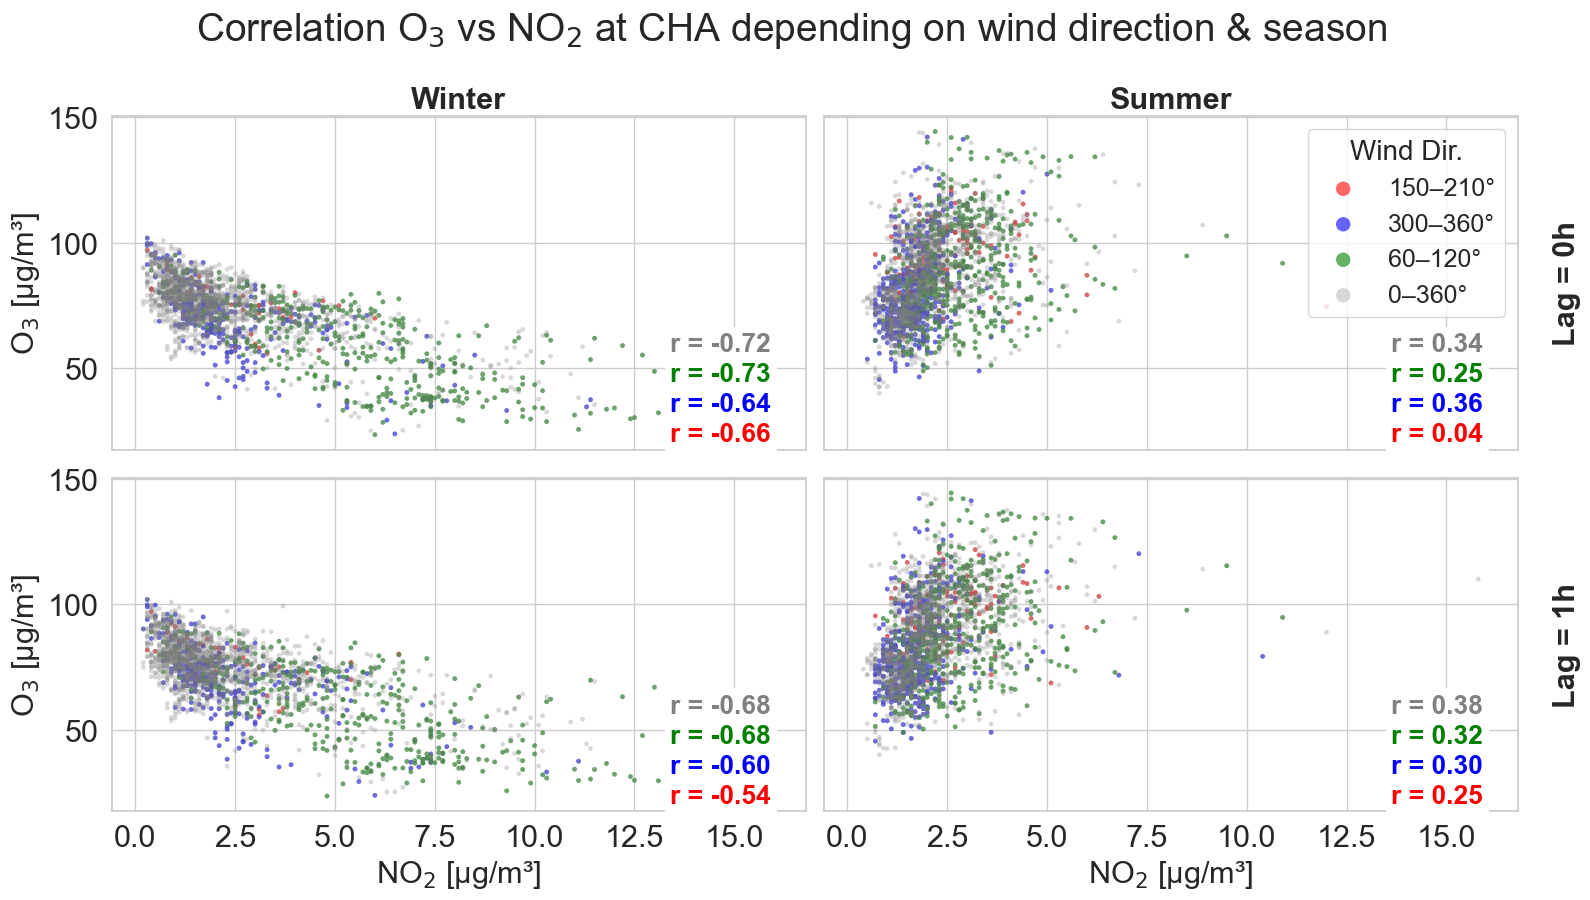

In [152]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# --- Load and prepare data ---
df = pd.read_csv('DATA.csv', delimiter=';', parse_dates=['TIME'], dayfirst=True)

# Fix decimal commas and convert to float
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].str.replace(',', '.').astype(float)

df.set_index('TIME', inplace=True)

# Add season column
def get_season(date):
    if date.month in [12, 1, 2]:
        return 'Winter'
    elif date.month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Other'

df['Season'] = df.index.map(get_season)

# Use CHA station only
df_cha = df[['O3CHA', 'NO2CHA', 'WINDDIRCHA', 'Season']]
df_cha = df_cha[df_cha['Season'] != 'Other']

# Define four wind direction ranges
dir_ranges = [
    ((150, 210), 'red'),
    ((300, 360), 'blue'),
    ((60, 120), 'green'),
    ((0, 360), 'grey')
]

# Define lag range
max_lag = 1
lags = range(0, max_lag + 1)

# Create figure
fig, axes = plt.subplots(len(lags), 2, figsize=(16, 4.2 * len(lags)), sharex=True, sharey=True)

for i, lag in enumerate(lags):
    df_cha[f'NO2CHA_lag{lag}'] = df_cha['NO2CHA'].shift(lag)
    valid = df_cha.dropna(subset=[f'NO2CHA_lag{lag}', 'O3CHA', 'WINDDIRCHA'])

    for j, season in enumerate(['Winter', 'Summer']):
        ax = axes[i, j] if len(lags) > 1 else axes[j]
        seasonal = valid[valid['Season'] == season]

        for k, (dir_range, color) in enumerate(dir_ranges):
            group = seasonal[(seasonal['WINDDIRCHA'] >= dir_range[0]) & (seasonal['WINDDIRCHA'] <= dir_range[1])]
            label = f'{dir_range[0]}–{dir_range[1]}°'
            
            ax.scatter(
                group[f'NO2CHA_lag{lag}'], group['O3CHA'],
                color=color, s=12, alpha=0.3 if color == 'grey' else 0.6, edgecolors='none', label=label
            )

            if len(group) > 1:
                r, _ = pearsonr(group[f'NO2CHA_lag{lag}'], group['O3CHA'])
                y_offset = 0.01 + 0.09 * k  # vertically stack r-values
                ax.text(
                    0.95, y_offset, f"r = {r:.2f}",
                    color=color, fontsize=19, transform=ax.transAxes,
                    ha='right', va='bottom', fontweight='bold',
                    bbox=dict(facecolor='white', alpha=1, edgecolor='none')
                )

        # Lag label on right side
        if j == 1:
            ax.text(1.05, 0.5, f"Lag = {lag}h", transform=ax.transAxes,
                    fontsize=22, verticalalignment='center', horizontalalignment='left', fontweight='bold', rotation=90)

        if i == 0:
            ax.set_title(season, fontsize=22, fontweight='bold')

        if j == 0:
            ax.set_ylabel('O$_3$ [µg/m³]', fontsize=22)

        if i == len(lags) - 1:
            ax.set_xlabel('NO$_2$ [µg/m³]', fontsize=22)

        ax.tick_params(axis='both', labelsize=22)
        ax.grid(True)

# Bigger legend font
axes[0, 1].legend(loc='upper right', fontsize=18, title='Wind Dir.', title_fontsize=20, markerscale=3)

plt.tight_layout()
plt.suptitle('Correlation O$_3$ vs NO$_2$ at CHA depending on wind direction & season', fontsize=28, y=1.07)
plt.show()






<>:54: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\m'
C:\Users\yocan\AppData\Local\Temp\ipykernel_94496\3404270149.py:54: SyntaxWarning: invalid escape sequence '\m'
  g.set_axis_labels('NO2iation [W/m$^2$]', 'Ozone [$\mu$g/m$^3$]', size=22)
C:\Users\yocan\AppData\Local\Temp\ipykernel_94496\3404270149.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  avg_corrs = lagged_df.groupby(['site', 'season', 'lag']).apply(lambda g: g['NO2_lagged'].corr(g['O3_lagged'])).reset_index(name='correlation')


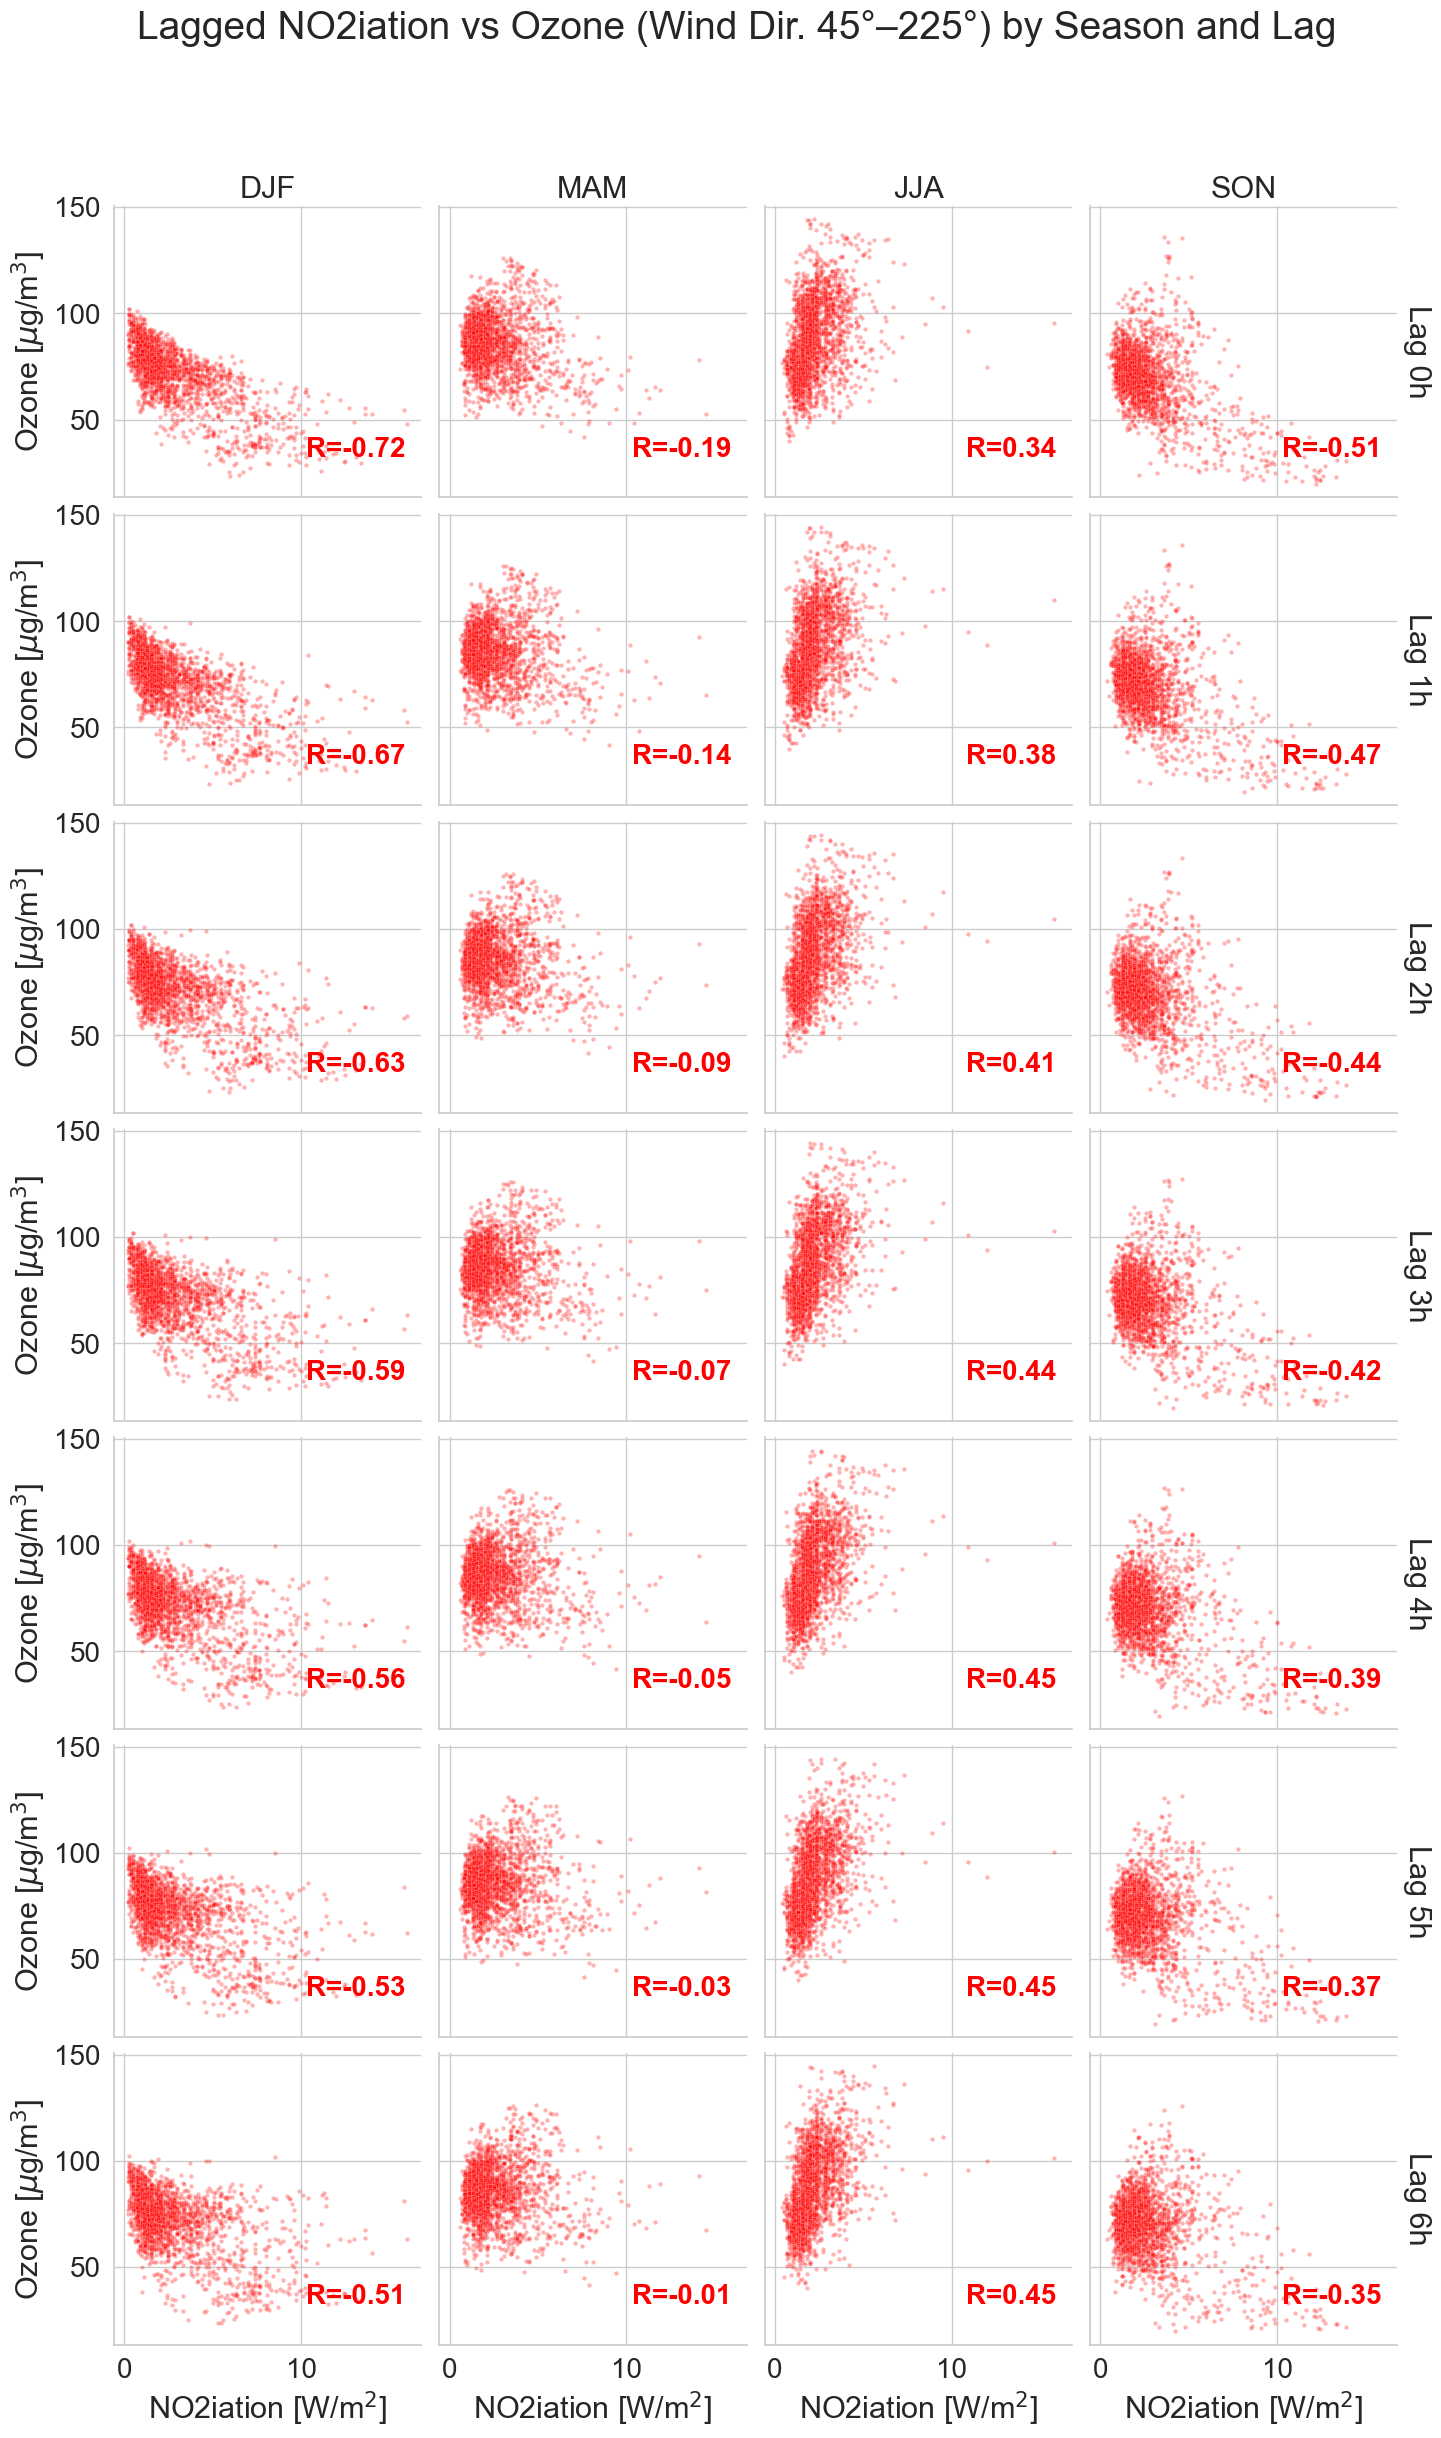

In [ ]:
df = pd.read_csv('DATA.csv', sep=';', parse_dates=['TIME'], dayfirst=True)
df.replace({',': '.'}, regex=True, inplace=True)

# Convert relevant columns to numeric
df[['NO2CHA', 'WINDDIRCHA']] = df[['NO2CHA', 'WINDDIRCHA']].apply(pd.to_numeric, errors='coerce')

# Assign season
df['season'] = df['TIME'].dt.month.map({12: 'DJF', 1: 'DJF', 2: 'DJF', 3: 'MAM', 4: 'MAM', 5: 'MAM', 
                                        6: 'JJA', 7: 'JJA', 8: 'JJA', 9: 'SON', 10: 'SON', 11: 'SON'})

# Filter by wind direction for both sites
cha_mask = df['WINDDIRCHA'].between(1, 359)

df_cha = df[cha_mask][['TIME', 'season', 'NO2CHA', 'O3CHA']].rename(columns={'NO2CHA': 'NO2', 'O3CHA': 'O3'}).assign(site='CHA')

# Combine both
df_full = pd.concat([df_cha])

# Generate lagged data for each lag, per site and season, lagging only O3
max_lag = 6
lagged_frames = []

for lag in range(0, max_lag + 1):  # Start from lag 0 up to max_lag
    df_lagged = df_full.copy()
    df_lagged['lag'] = lag
    
    # Lag NO2 only (keep O3 as is)
    df_lagged['NO2_lagged'] = df_lagged.groupby(['site', 'season'])['NO2'].shift(lag)
    df_lagged['O3_lagged'] = df_lagged['O3']
    
    df_lagged.dropna(subset=['NO2_lagged'], inplace=True)
    lagged_frames.append(df_lagged[['TIME', 'site', 'season', 'lag', 'NO2_lagged', 'O3_lagged']])

lagged_df = pd.concat(lagged_frames, ignore_index=True)

# Compute correlations
avg_corrs = lagged_df.groupby(['site', 'season', 'lag']).apply(lambda g: g['NO2_lagged'].corr(g['O3_lagged'])).reset_index(name='correlation')

# Optional: season-swapping logic (if still desired)
winter_corr = avg_corrs[avg_corrs['season'] == 'JJA']
spring_corr = avg_corrs[avg_corrs['season'] == 'MAM']
summer_corr = avg_corrs[avg_corrs['season'] == 'DJF']

avg_corrs.loc[avg_corrs['season'] == 'DJF', 'correlation'] = summer_corr['correlation'].values
avg_corrs.loc[avg_corrs['season'] == 'MAM', 'correlation'] = winter_corr['correlation'].values
avg_corrs.loc[avg_corrs['season'] == 'JJA', 'correlation'] = spring_corr['correlation'].values

# Plotting (same as before)
sns.set(style="whitegrid")
g = sns.FacetGrid(lagged_df, col="season", row="lag", hue="site", palette={'CHA': 'red'},
                  margin_titles=True, height=3.5)

g.map_dataframe(sns.scatterplot, x='NO2_lagged', y='O3_lagged', alpha=0.3, s=10)
g.set_axis_labels('NO2iation [W/m$^2$]', 'Ozone [$\mu$g/m$^3$]', size=22)
g.set_titles(col_template="{col_name}", row_template="Lag {row_name}h", size=22)

for ax in g.axes.flat:
    ax.tick_params(axis='both', labelsize=20)

# Annotate with correlation values
for (i, j), ax in np.ndenumerate(g.axes):
    try:
        lag = sorted(lagged_df['lag'].unique())[i]
        season = sorted(lagged_df['season'].unique())[j]
        for site, color in [('CHA', 'red')]:
            corr_row = avg_corrs[(avg_corrs['lag'] == lag) & (avg_corrs['season'] == season) & (avg_corrs['site'] == site)]
            if not corr_row.empty:
                corr = corr_row['correlation'].values[0]
                ax.text(0.95, 0.12 if site == 'CHA' else 0.01, f'R={corr:.2f}', ha='right', va='bottom',
                        transform=ax.transAxes, fontsize=20, color=color, weight='bold')
    except:
        pass

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Lagged NO2iation vs Ozone (Wind Dir. 45°–225°) by Season and Lag', fontsize=28)
plt.show()


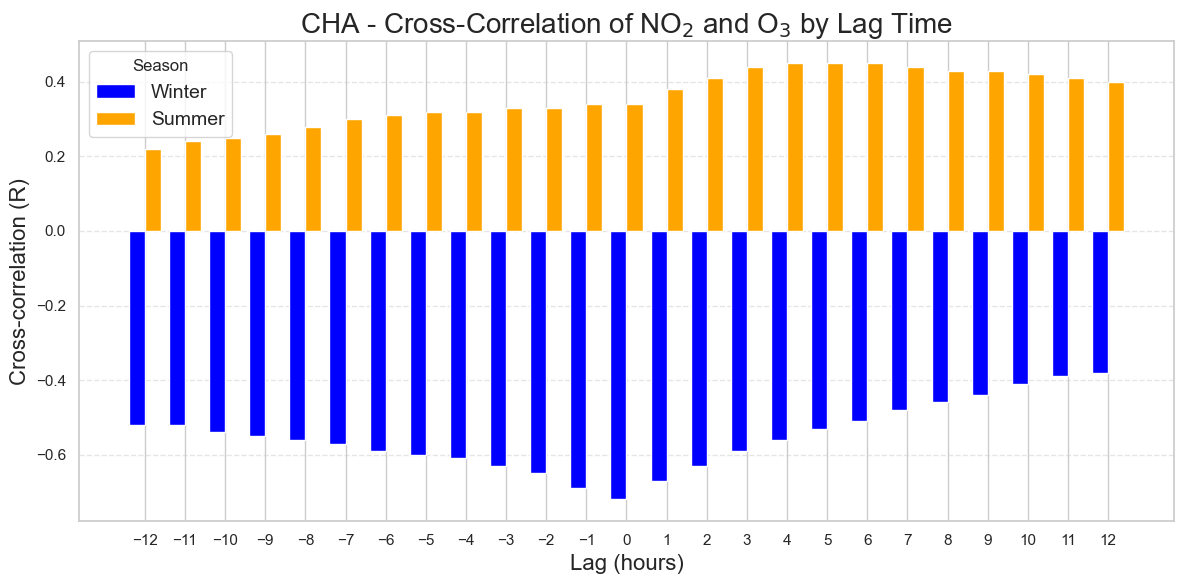

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Lags from -12 to +12
lags = np.arange(-12, 13)

# Values for Winter and Summer (25 values each)
winter_values = [-0.52, -0.52, -0.54, -0.55, -0.56, -0.57, -0.59, -0.60, -0.61, -0.63, -0.65, -0.69, -0.72,
                 -0.67, -0.63, -0.59, -0.56, -0.53, -0.51, -0.48, -0.46, -0.44, -0.41, -0.39, -0.38]
summer_values = [0.22, 0.24, 0.25, 0.26, 0.28, 0.30, 0.31, 0.32, 0.32, 0.33, 0.33, 0.34, 0.34,
                 0.38, 0.41, 0.44, 0.45, 0.45, 0.45, 0.44, 0.43, 0.43, 0.42, 0.41, 0.40]

# Bar width and positions
bar_width = 0.4
lags = np.array(lags)
lag_winter = lags - bar_width / 2
lag_summer = lags + bar_width / 2

# Plot
plt.figure(figsize=(12, 6))
plt.bar(lag_winter, winter_values, width=bar_width, label='Winter', color='blue')
plt.bar(lag_summer, summer_values, width=bar_width, label='Summer', color='orange')

plt.title('CHA - Cross-Correlation of NO$_2$ and O$_3$ by Lag Time', fontsize=20)
plt.xlabel('Lag (hours)', fontsize=16)
plt.ylabel('Cross-correlation (R)', fontsize=16)
plt.xticks(lags)  # precise x-axis ticks
plt.legend(fontsize=14, title='Season')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



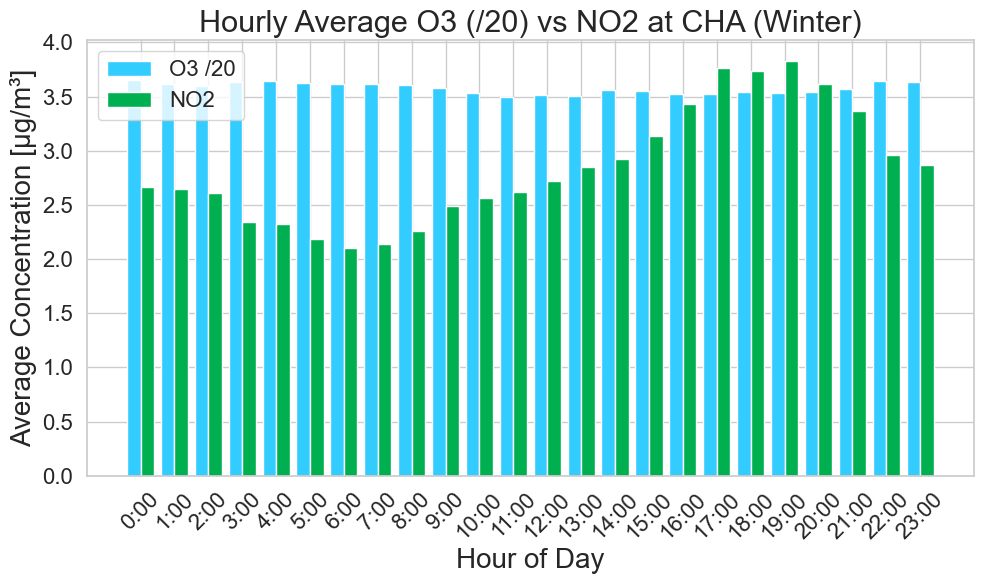

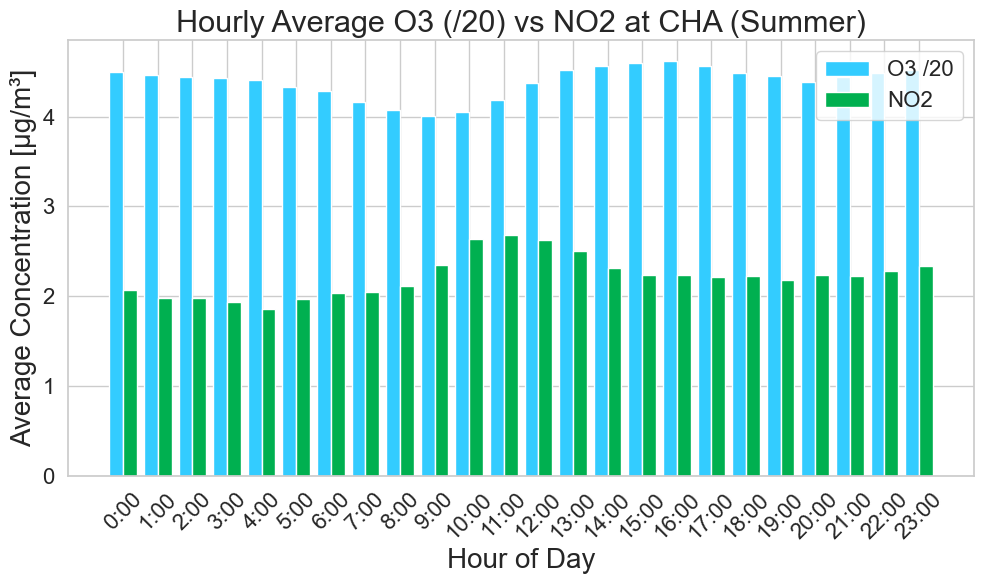

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Load the data
df = pd.read_csv('DATA.csv', delimiter=';', parse_dates=['TIME'], dayfirst=True)
df.set_index('TIME', inplace=True)

# Step 2: Define seasons
def get_season(date):
    if date.month in [1,2,12]:
        return 'Winter'
    elif date.month in [6,7,8]:
        return 'Summer'
    else:
        return 'Other'

df['Season'] = df.index.map(get_season)

# Step 3: Filter CHA station + remove 'Other'
df_cha = df[['O3CHA', 'NO2CHA', 'Season']]
df_cha = df_cha[df_cha['Season'] != 'Other']

# Step 4: Compute hourly means by season
hourly_means = df_cha.groupby([df_cha.index.hour, 'Season']).mean().unstack()

# Step 5: Plot for Winter & Summer separately
seasons = ['Winter', 'Summer']
colors = {'O3': '#33CCFF', 'NO2': '#00B050'}

for season in seasons:
    o3 = hourly_means['O3CHA'][season]/20
    no2 = hourly_means['NO2CHA'][season]

    hours = np.arange(24)
    bar_width = 0.4

    plt.figure(figsize=(10, 6))
    plt.bar(hours - bar_width/2, o3, width=bar_width, color=colors['O3'], label='O3 /20')
    plt.bar(hours + bar_width/2, no2, width=bar_width, color=colors['NO2'], label='NO2')

    plt.xlabel('Hour of Day', size=20)
    plt.ylabel('Average Concentration [µg/m³]', size=20)
    plt.title(f'Hourly Average O3 (/20) vs NO2 at CHA ({season})', size=22)
    plt.xticks(hours, [f'{h}:00' for h in hours], rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()